In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)
tf.random.set_seed(42)

sys.path.append(os.path.abspath('..'))
from src.data_loader import SP500DataLoader

print("=" * 60)
print("SIMPLE LSTM — NO REGULARIZATION")
print("Comparison model for regularized LSTM")
print("=" * 60)

2026-06-27 12:24:39.301468: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


SIMPLE LSTM — NO REGULARIZATION
Comparison model for regularized LSTM


In [2]:
loader = SP500DataLoader(start_year=1997, end_year=2024)
df = loader.load_all()

all_returns  = df['log_returns'].dropna()
train_returns = all_returns['2010':'2019'].values

print(f"\nTraining data shape: {train_returns.shape}")
print(f"Date range: 2010-01-01 to 2019-12-31")


Training data shape: (2516,)
Date range: 2010-01-01 to 2019-12-31


In [3]:
lookback   = 60
vol_window = 20

def create_volatility_sequences(data, lookback=60, vol_window=20):
    """
    Identical to regularized model label creation.
    Input:  60-day window of raw log returns
    Label:  1 = next day HIGH volatility, 0 = LOW volatility
    """
    X, y = [], []
    for i in range(lookback, len(data) - 1):
        X.append(data[i-lookback:i])
        recent_vol = np.abs(data[i-vol_window:i]).mean()
        next_vol   = np.abs(data[i+1])
        y.append(1 if next_vol > recent_vol else 0)
    return np.array(X), np.array(y)

X, y = create_volatility_sequences(train_returns, lookback, vol_window)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class balance — HIGH: {y.sum()} ({y.mean()*100:.1f}%), "
      f"LOW: {len(y)-y.sum()} ({(1-y.mean())*100:.1f}%)"


X shape: (2455, 60)
y shape: (2455,)
Class balance — HIGH: 992 (40.4%), LOW: 1463 (59.6%)


In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# Scaler fitted on training data only — identical rule
scaler_simple = StandardScaler()
X_train_scaled = scaler_simple.fit_transform(
    X_train.reshape(-1, lookback)
).reshape(-1, lookback, 1)

X_val_scaled = scaler_simple.transform(
    X_val.reshape(-1, lookback)
).reshape(-1, lookback, 1)

print(f"\nTrain shape: {X_train_scaled.shape}")
print(f"Validation shape: {X_val_scaled.shape}")


classes = np.unique(y_train)
class_weights = compute_class_weight(
    'balanced', classes=classes, y=y_train

)
class_weight_dict = dict(zip(classes, class_weights))
print(f"Class weights: {class_weight_dict}")


Train shape: (1964, 60, 1)
Validation shape: (491, 60, 1)
Class weights: {0: 0.8343245539507221, 1: 1.2477763659466328}


In [5]:
def build_simple_lstm(lookback=60, lstm_units=32):
    """
    Simple LSTM with NO regularization.
    Identical architecture to regularized model EXCEPT:
    - No Dropout(0.2) after LSTM
    - No Dropout(0.2) after Dense(16)
    - No ReduceLROnPlateau callback
    - Default learning rate 0.001 (not tuned to 0.0005)
    This isolates exactly what regularization contributes.
    """
    model = Sequential([
        LSTM(lstm_units,
             return_sequences=False,
             input_shape=(lookback, 1)),
        
        Dense(16, activation='relu'),
        # NO Dropout here — this is the key difference
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',      # default lr=0.001, not tuned
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

simple_model = build_simple_lstm(lookback=lookback, lstm_units=32)
simple_model.summary()
print("\n✅ Simple LSTM built — no Dropout, default learning rate")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)


✅ Simple LSTM built — no Dropout, default learning rate


In [6]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("\n" + "="*60)
print("TRAINING SIMPLE LSTM")
print("="*60)

history = simple_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training complete!")


TRAINING SIMPLE LSTM
Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6242 - loss: 0.6847 - val_accuracy: 0.6375 - val_loss: 0.6647
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6105 - loss: 0.6689 - val_accuracy: 0.6314 - val_loss: 0.6466
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6013 - loss: 0.6637 - val_accuracy: 0.6436 - val_loss: 0.6419
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6039 - loss: 0.6624 - val_accuracy: 0.6395 - val_loss: 0.6396
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6044 - loss: 0.6612 - val_accuracy: 0.6497 - val_loss: 0.6391
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6023 - loss: 0.6604 - val_accuracy: 0.6436 - val_loss: 0.6385
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6059 - loss: 0.6597 - val_accuracy: 0.6477 - val_loss: 0.6379
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6003 - loss: 0.6

In [7]:
val_loss, val_acc = simple_model.evaluate(
    X_val_scaled, y_val, verbose=0
)
val_preds = (simple_model.predict(
    X_val_scaled, verbose=0
).flatten() > 0.5).astype(int)

val_bacc = balanced_accuracy_score(y_val, val_preds) * 100

print(f"\nSimple LSTM validation results:")
print(f"  Accuracy:          {val_acc*100:.2f}%")
print(f"  Balanced accuracy: {val_bacc:.2f}%")
print(f"  Loss:              {val_loss:.4f}")
print(f"\nRegularized LSTM for comparison:")
print(f"  Accuracy:          66.80%")
print(f"  Balanced accuracy: 64.76%")
print(f"  Loss:              0.6346")


Simple LSTM validation results:
  Accuracy:          64.77%
  Balanced accuracy: 64.44%
  Loss:              0.6368

Regularized LSTM for comparison:
  Accuracy:          66.80%
  Balanced accuracy: 64.76%
  Loss:              0.6346


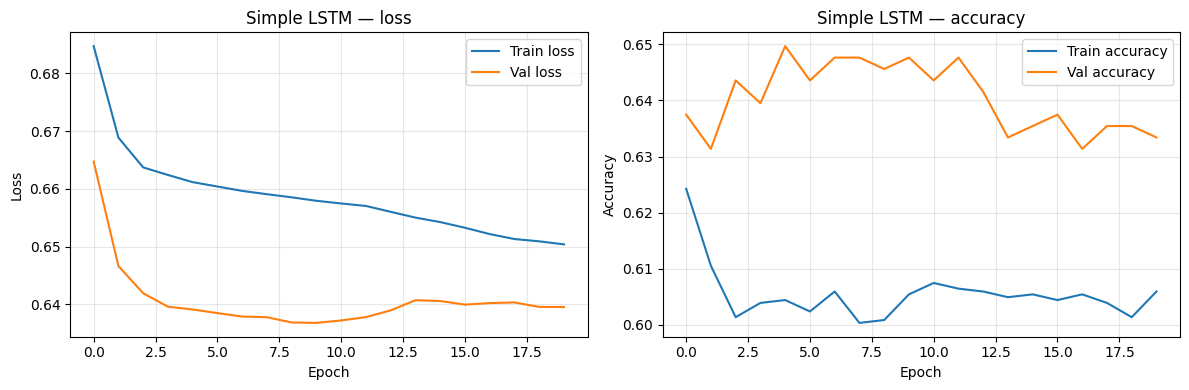

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Simple LSTM — loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val accuracy')
axes[1].set_title('Simple LSTM — accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/simple_lstm_training.png', dpi=150)
plt.show()

In [10]:
print("\n" + "="*60)
print("STRESS TESTING SIMPLE LSTM")
print("="*60)

data_path = '../data/simulated/'

scenario_paths = {
    'Normal':             np.load(f'{data_path}mc_returns_normal.npy'),
    '2008 Crisis':        np.load(f'{data_path}mc_returns_crisis_2008.npy'),
    'COVID Crisis':       np.load(f'{data_path}mc_returns_crisis_covid.npy'),
    'Synthetic Extreme':  np.load(f'{data_path}mc_returns_synthetic_extreme.npy'),
    'Non-linear Squeeze': np.load(f'{data_path}mc_returns_squeeze.npy'),
    'Structural Break':   np.load(f'{data_path}mc_returns_structural_break.npy'),
}

def get_volatility_labels_mc(paths, lookback=60, vol_window=20):
    """Vectorised label extraction — identical to regularized model."""
    recent_vol = np.abs(
        paths[:, -(vol_window+1):-1]
    ).mean(axis=1)
    next_vol = np.abs(paths[:, -1])
    return (next_vol > recent_vol).astype(int)


def predict_simple(model, scaler, paths, lookback=60, batch_size=500):
    """
    Stress test prediction for simple LSTM.
    Uses scaler_simple — fitted on simple model training data.
    Feature window: path[:, -(lookback+1):-1] to avoid
    look-ahead between features and label target.
    """
    n_paths   = paths.shape[0]
    all_probs = []

    for i in range(0, n_paths, batch_size):
        batch    = paths[i:i+batch_size]
        features = batch[:, -(lookback+1):-1]
        features_scaled = scaler.transform(features)
        features_scaled = features_scaled.reshape(-1, lookback, 1)
        probs = model.predict(features_scaled, verbose=0)
        all_probs.extend(probs.flatten())

    return np.array(all_probs)

simple_results = {}
baseline_reg   = 49.90   # 

print(f"\n{'Scenario':<22} {'Simple LSTM':>12} {'Reg LSTM':>10} {'Difference':>12}")
print("-"*60)

# Regularized model results for comparison
reg_results = {
    'Normal':             49.90,
    '2008 Crisis':        49.58,
    'COVID Crisis':       49.05,
    'Synthetic Extreme':  49.79,
    'Non-linear Squeeze': 50.95,
    'Structural Break':   49.26,
}

for scenario, paths in scenario_paths.items():
    labels    = get_volatility_labels_mc(paths)
    probs     = predict_simple(simple_model, scaler_simple, paths)
    preds     = (probs > 0.5).astype(int)
    acc       = (preds == labels).mean() * 100
    simple_results[scenario] = acc
    diff      = acc - reg_results[scenario]
    direction = "Simple better" if diff > 0 else "Reg better"
    print(f"{scenario:<22} {acc:>11.2f}% {reg_results[scenario]:>9.2f}% "
          f"{diff:>+10.2f}pp  ({direction})")




STRESS TESTING SIMPLE LSTM

Scenario                Simple LSTM   Reg LSTM   Difference
------------------------------------------------------------
Normal                       50.64%     49.90%      +0.74pp  (Simple better)
2008 Crisis                  49.40%     49.58%      -0.18pp  (Reg better)
COVID Crisis                 49.88%     49.05%      +0.83pp  (Simple better)
Synthetic Extreme            49.31%     49.79%      -0.48pp  (Reg better)
Non-linear Squeeze           49.74%     50.95%      -1.21pp  (Reg better)
Structural Break             50.68%     49.26%      +1.42pp  (Simple better)


In [11]:
print("\n" + "="*60)
print("DEGRADATION ANALYSIS — SIMPLE vs REGULARIZED")
print("="*60)

simple_baseline = simple_results['Normal']
reg_baseline    = reg_results['Normal']

print(f"\n{'Scenario':<22} {'Simple Δpp':>11} {'Reg Δpp':>10} {'Reg more stable?':>17}")
print("-"*65)

for scenario in scenario_paths:
    if scenario == 'Normal':
        continue
    simple_d = simple_results[scenario] - simple_baseline
    reg_d    = reg_results[scenario]    - reg_baseline
    more_stable = "✅ Yes" if abs(reg_d) < abs(simple_d) else "❌ No"
    print(f"{scenario:<22} {simple_d:>+10.2f}pp {reg_d:>+9.2f}pp "
          f"{more_stable:>17}")



DEGRADATION ANALYSIS — SIMPLE vs REGULARIZED

Scenario                Simple Δpp    Reg Δpp  Reg more stable?
-----------------------------------------------------------------
2008 Crisis                 -1.24pp     -0.32pp             ✅ Yes
COVID Crisis                -0.76pp     -0.85pp              ❌ No
Synthetic Extreme           -1.33pp     -0.11pp             ✅ Yes
Non-linear Squeeze          -0.90pp     +1.05pp              ❌ No
Structural Break            +0.04pp     -0.64pp              ❌ No


In [12]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

n = 10000

simple_res = {
    'Normal':             50.64,
    '2008 Crisis':        49.40,
    'COVID Crisis':       49.88,
    'Synthetic Extreme':  49.31,
    'Non-linear Squeeze': 49.74,
    'Structural Break':   50.68,
}

reg_res = {
    'Normal':             49.90,
    '2008 Crisis':        49.58,
    'COVID Crisis':       49.05,
    'Synthetic Extreme':  49.79,
    'Non-linear Squeeze': 50.95,
    'Structural Break':   49.26,
}

print(f"{'Scenario':<22} {'Δpp':>7} {'z-stat':>8} {'p-value':>10} {'Sig':>6}")
print("-"*60)

for scenario in simple_res:
    simple_acc = simple_res[scenario]
    reg_acc    = reg_res[scenario]
    delta      = reg_acc - simple_acc

    stat, p = proportions_ztest(
        count=[int(reg_acc/100 * n), int(simple_acc/100 * n)],
        nobs=[n, n],
        alternative='two-sided'
    )

    if p < 0.001:
        sig = '***'
    elif p < 0.01:
        sig = '**'
    elif p < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    print(f"{scenario:<22} {delta:>+6.2f}pp {stat:>8.3f} {p:>10.6f} {sig:>6}")

Scenario                   Δpp   z-stat    p-value    Sig
------------------------------------------------------------
Normal                  -0.74pp   -1.047   0.295315     ns
2008 Crisis             +0.18pp    0.255   0.799054     ns
COVID Crisis            -0.83pp   -1.174   0.240449     ns
Synthetic Extreme       +0.48pp    0.679   0.497233     ns
Non-linear Squeeze      +1.21pp    1.711   0.087037     ns
Structural Break        -1.42pp   -2.008   0.044624      *
